# Data structures accepted by seaborn

📄 Source: https://seaborn.pydata.org/tutorial/data_structure.html

Seaborn accepts pandas and numpy objects, plus lists and dicts. The key distinction is **long-form vs wide-form** data, and seaborn treats them differently.
(A few older functions such as `lmplot` and `regplot` accept fewer formats.)

🔗 This is why pandas `melt()` matters ([pandas User Guide, Part 6](../../pandas%20-%20official%20User%20Guide/README.md)).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
print("seaborn", sns.__version__, "| pandas", pd.__version__)

seaborn 0.13.2 | pandas 3.0.2


## Long-form vs. wide-form data

Most seaborn functions work with **vectors** of data (`x` is a vector, `y` is a vector). A dataset with several vectors can be laid out in two ways.

### Long-form data

- Each **variable** is a column
- Each **observation** is a row

The "flights" dataset: passengers per month, 1949-1960. Three variables: *year*, *month*, *passengers*.

In [2]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


With long-form data you give columns a **role** by assigning them by name:

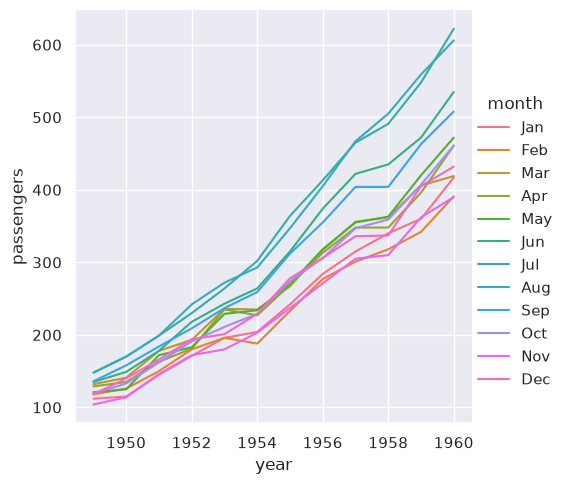

In [3]:
sns.relplot(data=flights, x="year", y="passengers", hue="month", kind="line")

Long-form is explicit and handles any complexity, but it's often not how we picture the data in our heads.

### Wide-form data

Like a spreadsheet: rows and columns hold *levels* of variables. **Pivot** flights so each column is one month's series over the years:

In [4]:
flights_wide = flights.pivot(index="year", columns="month", values="passengers")
flights_wide.head()

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201


Same three variables, but now they live in the **dimensions** of the table (index = year, columns = month, cells = passengers), not in named columns.

> Seaborn treats `data` as **wide-form when neither `x` nor `y` is assigned**.

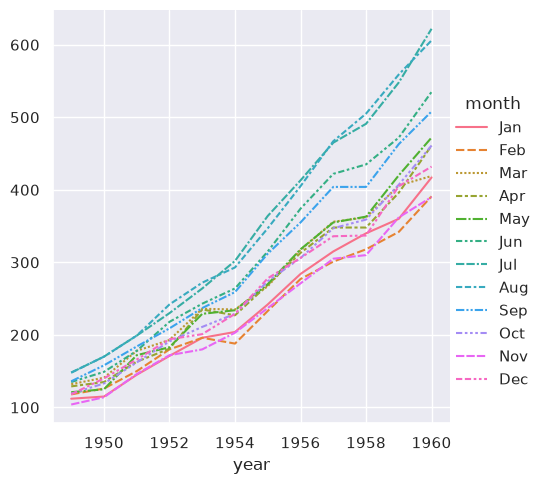

In [5]:
sns.relplot(data=flights_wide, kind="line")   # index -> x, values -> y, one line per column

Almost the same plot, but the pivot **lost the meaning of the values**: there's no y-axis label. (Lines are also dashed because `relplot` mapped the columns to both `hue` and `style`.)

The big advantage of long-form: once the data is in shape, you only think about **variables**, not structure. Monthly lines per year? Just swap the roles:

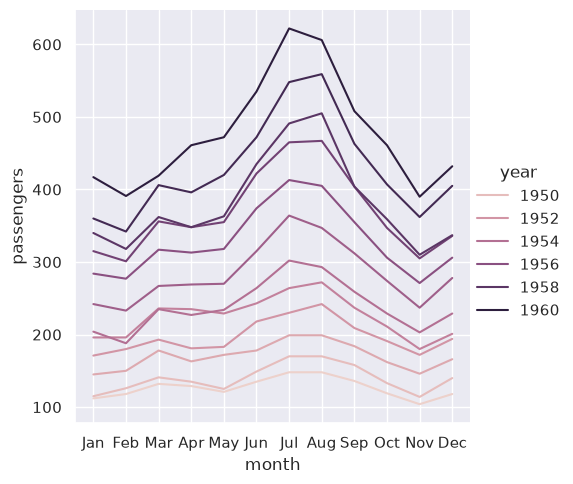

In [6]:
sns.relplot(data=flights, x="month", y="passengers", hue="year", kind="line")

With wide-form we'd have to **transpose** the table:

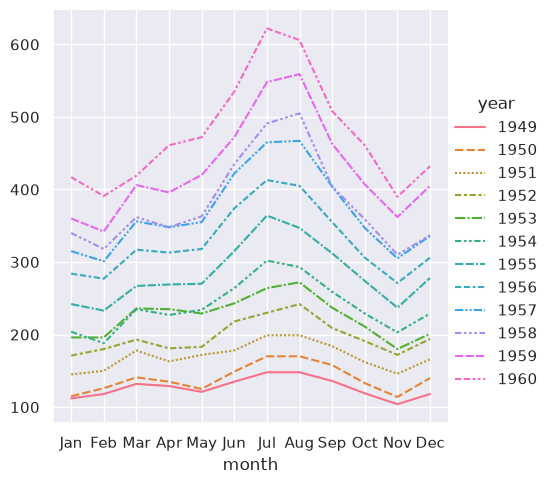

In [7]:
sns.relplot(data=flights_wide.transpose(), kind="line")

Note: in wide-form, the column variable is always treated as **categorical** (so `year` got a categorical palette here, but a numeric gradient in long-form).

Each plot type also needs its own fixed mapping of the table's dimensions, so wide-form results are less predictable. Categorical plots put the **columns** on `x` and aggregate over the rows (ignoring the index):

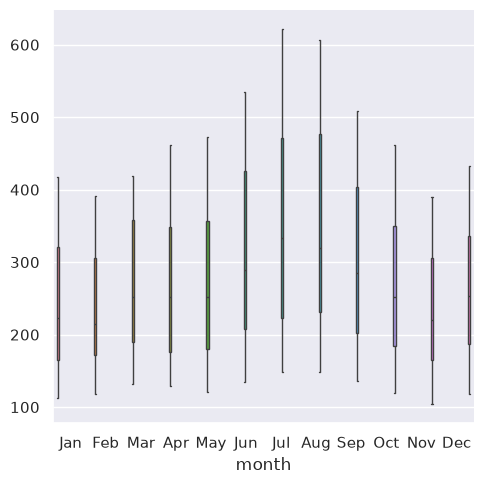

In [8]:
sns.catplot(data=flights_wide, kind="box")   # one box per month, across all years

Wide-form pandas data holds at most ~3 variables (seaborn ignores MultiIndex info). For N-dimensional labelled data (`xarray`), convert it to a long-form DataFrame first.

**In summary:**

| Long-form | Wide-form |
| :-- | :-- |
| one column per variable, one row per observation | variables encoded in the row index, column index and cell values |
| assign roles by name: `x=`, `y=`, `hue=` | seaborn assigns roles from the table's dimensions |
| any number of variables | ≤ 3 variables |

### Messy data

Some datasets are neither: variables are defined neither by keys nor by dimensions. Typical for **repeated-measures** data, where each row is a *unit* (a subject).
Example: 20 subjects did an anagram memory task with *divided* or *focused* attention:

In [9]:
anagrams = sns.load_dataset("anagrams")
anagrams

,subidr,attnr,num1,num2,num3
0,1,divided,2,4.0,7
1,2,divided,3,4.0,5
2,3,divided,3,5.0,6
3,4,divided,5,7.0,5
4,5,divided,4,5.0,8
5,6,divided,5,5.0,6
6,7,divided,5,4.5,6
7,8,divided,5,7.0,8
8,9,divided,2,3.0,7
9,10,divided,6,5.0,6


`attnr` is between-subjects, but there's also a within-subjects variable: the **number of solutions** (1-3), spread across the columns `num1`, `num2`, `num3` together with the **score**. So two variables are encoded jointly in several columns.

To plot average score vs attention and number of solutions, first make it **tidy long-form** with `melt`:

In [10]:
anagrams_long = anagrams.melt(
    id_vars=["subidr", "attnr"],   # columns to keep as identifiers
    var_name="solutions",          # old column names (num1/num2/num3) go into this new column
    value_name="score",            # old cell values go into this new column
)
anagrams_long.head()

,subidr,attnr,solutions,score
0,1,divided,num1,2.0
1,2,divided,num1,3.0
2,3,divided,num1,3.0
3,4,divided,num1,5.0
4,5,divided,num1,4.0


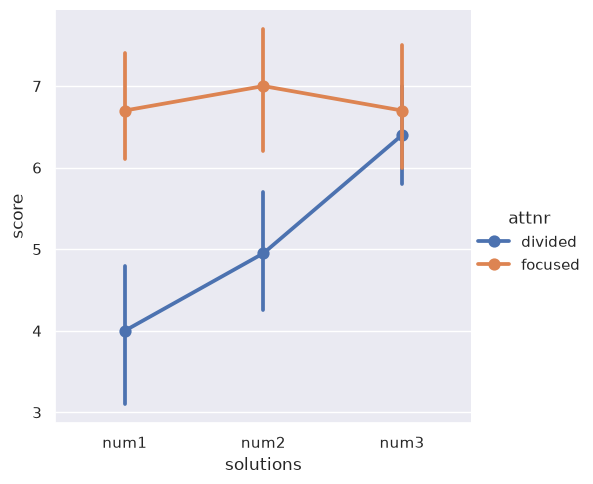

In [11]:
sns.catplot(data=anagrams_long, x="solutions", y="score", hue="attnr", kind="point")   # mean score + CI per group

### Further reading and take-home points

See Hadley Wickham's *Tidy Data* paper. Seaborn distinguishes "tidy wide-form" (clear mapping between variables and table dimensions) from "messy" data (no clear mapping).

**When possible, use long-form for serious analysis.** You assign variables to roles explicitly and can use more than three. Most seaborn docs use long-form.

## Options for visualizing long-form data

Long-form doesn't have to be a DataFrame. A **dict** (or anything with that interface) works:

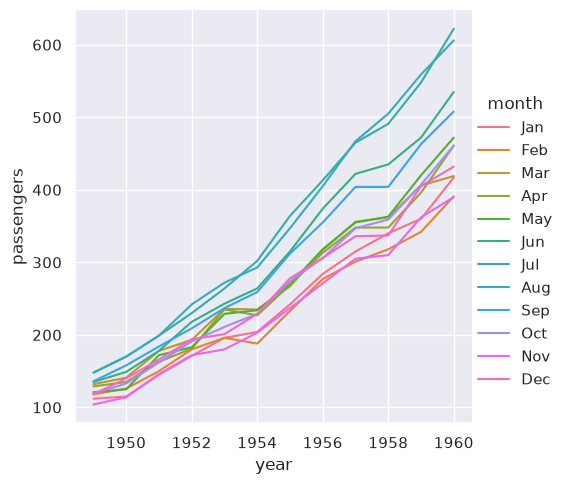

In [12]:
flights_dict = flights.to_dict()   # {column: {row: value}}
sns.relplot(data=flights_dict, x="year", y="passengers", hue="month", kind="line")

After a groupby, the key moves into the **index**. As long as it keeps its name, you can still reference it:

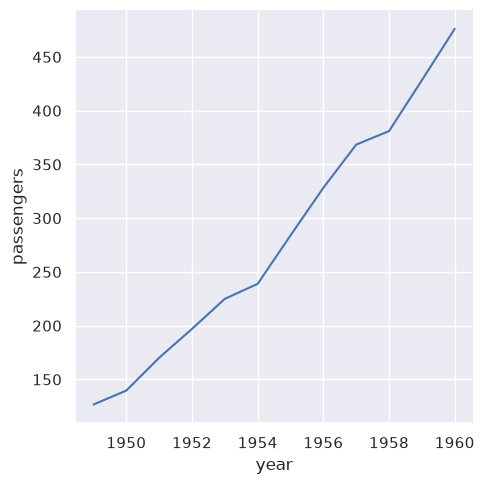

In [13]:
flights_avg = flights.groupby("year").mean(numeric_only=True)   # 'year' is now the index
sns.relplot(data=flights_avg, x="year", y="passengers", kind="line")   # still works by name

You can also pass vectors directly to `x`, `y`... If they are pandas objects, their `name` labels the axes:

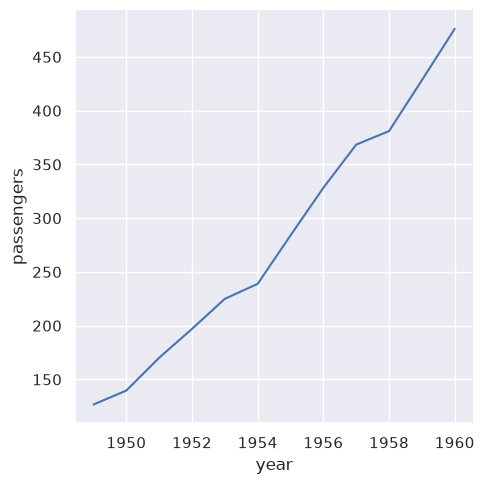

In [14]:
year = flights_avg.index
passengers = flights_avg["passengers"]
sns.relplot(x=year, y=passengers, kind="line")

Numpy arrays and lists work too, but without names the plot is less informative (no axis labels):

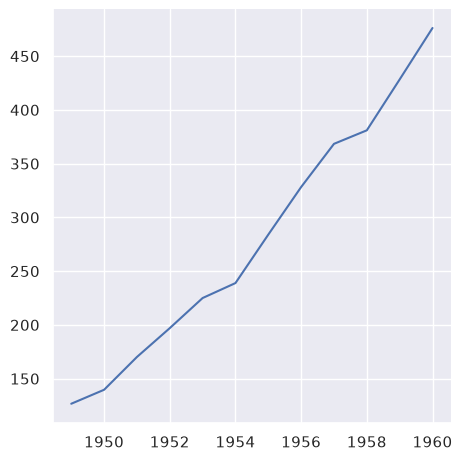

In [15]:
sns.relplot(x=year.to_numpy(), y=passengers.to_list(), kind="line")

## Options for visualizing wide-form data

Anything that can be seen as one vector or a collection of vectors can go into `data`. Pandas objects are best because names/index are used.
A list of Series works, but the axis labels are lost:

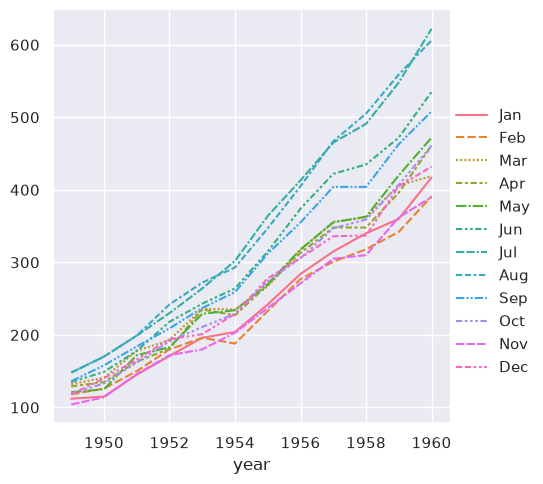

In [16]:
flights_wide_list = [col for _, col in flights_wide.items()]   # one Series per month
sns.relplot(data=flights_wide_list, kind="line")

Vectors don't need the same length. If they have an **index**, it is used to align them:

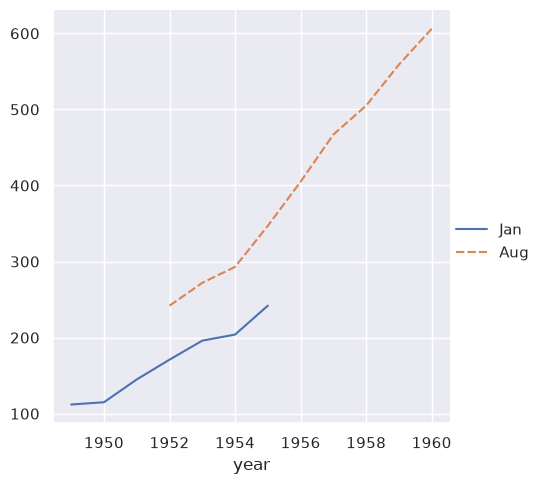

In [17]:
two_series = [flights_wide.loc[:1955, "Jan"], flights_wide.loc[1952:, "Aug"]]   # different year ranges
sns.relplot(data=two_series, kind="line")

Numpy arrays / plain sequences use an ordinal index (0, 1, 2...) instead:

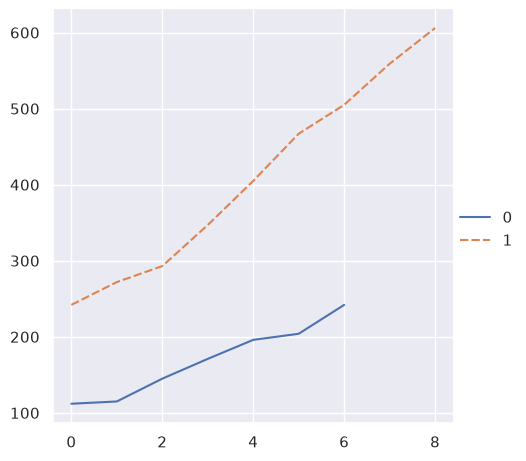

In [18]:
two_arrays = [s.to_numpy() for s in two_series]
sns.relplot(data=two_arrays, kind="line")

A dict of such vectors at least uses the **keys** as labels:

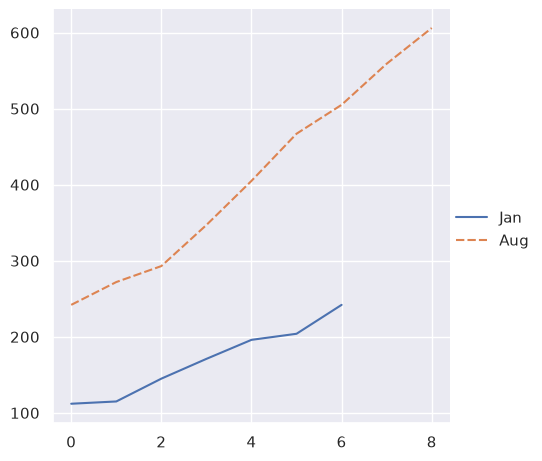

In [19]:
two_arrays_dict = {s.name: s.to_numpy() for s in two_series}
sns.relplot(data=two_arrays_dict, kind="line")

A rectangular numpy array is treated like a DataFrame without index info: a collection of **column** vectors (like pandas and matplotlib do, unlike numpy indexing which takes rows):

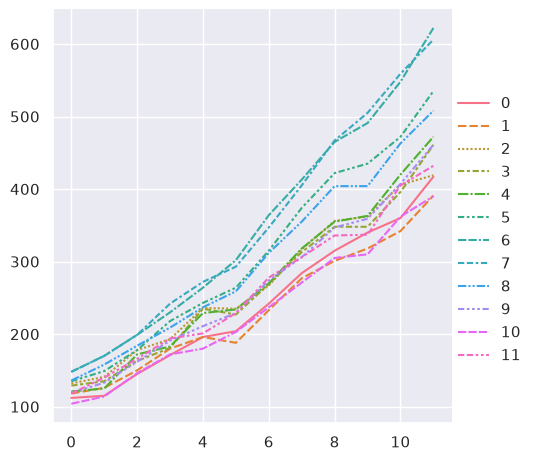

In [20]:
flights_array = flights_wide.to_numpy()
sns.relplot(data=flights_array, kind="line")

## Round trip check (my addition)

wide → long with `melt`, then back with `pivot_table`; the numbers must match exactly.

In [21]:
long_again = flights_wide.reset_index().melt(id_vars="year", var_name="month", value_name="passengers")
wide_again = long_again.pivot_table(index="year", columns="month", values="passengers", observed=False)

print("long rows:", len(long_again), "| same numbers after round trip:",
      np.array_equal(wide_again.to_numpy(), flights_wide.to_numpy()))

long rows: 144 | same numbers after round trip: False


## Key takeaways

- **Long-form** (one row per observation, one column per variable) is the format to aim for: `sns.func(data=df, x="col", y="col", hue="col")`.
- **Wide-form** works when neither `x` nor `y` is given, but loses value names and is less predictable.
- **Messy** data → `df.melt(id_vars=..., var_name=..., value_name=...)` first.
- Named pandas vectors label the axes; plain arrays don't.